# Etapa 2 — Análise Exploratória de Dados

Entrada: os CSVs que a Etapa 1 gravou em `../data/raw/`.
Saída: uma tabela horária limpa em `../data/processed/dataset.csv`, mais os
gráficos e as conclusões que sustentam o que você vai afirmar.

As seções abaixo são um roteiro, não uma receita. Responda as perguntas de
cada uma com código e, no fim, em texto. Acrescente seções se quiser.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DIR_RAW = Path("..") / "data" / "raw"
DIR_PROC = Path("..") / "data" / "processed"
DIR_PROC.mkdir(parents=True, exist_ok=True)

## 1. Carregar os CSVs

Leia os quatro arquivos de `../data/raw/`.

- Quantas linhas tem cada um? O número faz sentido para o período coletado?
- Os tipos vieram certos, ou datas e números chegaram como texto?
- Há colunas vazias, ou linhas duplicadas?

In [2]:
mares = pd.read_csv(DIR_RAW / "mares_2025.csv")
mares_prev = pd.read_csv(DIR_RAW / "mares_previsao.csv")
ondas = pd.read_csv(DIR_RAW / "ondas.csv")
vento = pd.read_csv(DIR_RAW / "vento.csv")

for nome, df in {"mares": mares, "mares_prev": mares_prev, "ondas": ondas, "vento": vento}.items():
    print(f"{nome:<11} {df.shape[0]:>5} linhas, {df.shape[1]} colunas")

mares        1410 linhas, 8 colunas
mares_prev    120 linhas, 8 colunas
ondas         168 linhas, 4 colunas
vento         168 linhas, 4 colunas


In [3]:
for nome, df in {"mares": mares, "mares_prev": mares_prev, "ondas": ondas, "vento": vento}.items():
    print(f"===== {nome}")
    print(df.dtypes)
    print("nulos:", df.isna().sum().sum(), "| duplicadas:", df.duplicated().sum())
    print()

===== mares
data               str
hora               str
altura_m       float64
tipo               str
coeficiente      int64
idade_lua        int64
nascer_sol         str
por_sol            str
dtype: object
nulos: 0 | duplicadas: 0

===== mares_prev
data               str
hora               str
altura_m       float64
tipo               str
coeficiente      int64
idade_lua        int64
nascer_sol         str
por_sol            str
dtype: object
nulos: 0 | duplicadas: 0

===== ondas
data                 str
hora                 str
altura_onda_m    float64
direcao_onda         str
dtype: object
nulos: 0 | duplicadas: 0

===== vento
data                 str
hora                 str
vento_kmh        float64
direcao_vento        str
dtype: object
nulos: 0 | duplicadas: 0



**Leitura:**

- `mares_2025`: 1410 linhas para 365 dias, ~3,9 marés por dia. Faz sentido: a
  maré tem período de ~12h25min, então alguns dias têm só 3 eventos (a 4ª maré
  "escorrega" para o dia seguinte).
- `mares_prev`: 120 linhas para os 31 dias de outubro de 2026 — mesmo raciocínio.
- `ondas` e `vento`: 168 linhas = 7 dias × 24 horas. Completo.
- Tipos: números (altura, coeficiente, vento) já vieram numéricos — a vírgula
  decimal foi tratada na Etapa 1. `data` e `hora` vieram como texto (`str`).
- Nenhum nulo e nenhuma linha duplicada.

## 2. Limpeza

Deixe cada tabela num estado em que dá para confiar.

- Datas e horas: viram `datetime`? Vale montar uma coluna única de data + hora?
- Decimais: o site usa vírgula. Isso já foi resolvido na Etapa 1 ou sobrou aqui?
- O que fazer com nulos: descartar a linha, preencher, ou manter e documentar?
- Duplicatas: existem? De onde vieram?

In [4]:
for df in [mares, mares_prev, ondas, vento]:
    df["datahora"] = pd.to_datetime(df["data"] + " " + df["hora"])
    df["data"] = pd.to_datetime(df["data"])
    df.sort_values("datahora", inplace=True, ignore_index=True)

mares.head()

,data,hora,altura_m,tipo,coeficiente,idade_lua,nascer_sol,por_sol,datahora
0,2025-01-01,05:50,2.4,alta,81,1,05:06,17:39,2025-01-01 05:50:00
1,2025-01-01,12:00,0.4,baixa,81,1,05:06,17:39,2025-01-01 12:00:00
2,2025-01-01,18:07,2.3,alta,81,1,05:06,17:39,2025-01-01 18:07:00
3,2025-01-02,00:19,0.4,baixa,80,2,05:06,17:40,2025-01-02 00:19:00
4,2025-01-02,06:31,2.4,alta,80,2,05:06,17:40,2025-01-02 06:31:00


In [5]:
for nome, df in {"mares": mares, "mares_prev": mares_prev, "ondas": ondas, "vento": vento}.items():
    print(f"{nome:<11} {df['datahora'].min()} → {df['datahora'].max()} | horários repetidos: {df['datahora'].duplicated().sum()}")

print("ondas e vento têm exatamente as mesmas horas?", ondas["datahora"].equals(vento["datahora"]))

mares       2025-01-01 05:50:00 → 2025-12-31 20:38:00 | horários repetidos: 0
mares_prev  2026-10-01 00:24:00 → 2026-10-31 20:58:00 | horários repetidos: 0
ondas       2026-10-08 00:00:00 → 2026-10-14 23:00:00 | horários repetidos: 0
vento       2026-10-08 00:00:00 → 2026-10-14 23:00:00 | horários repetidos: 0
ondas e vento têm exatamente as mesmas horas? True


**Leitura:**

- Datas e horas viraram `datetime` numa coluna única, `datahora`. É a chave
  para juntar as tabelas na seção 4.
- Decimais: resolvidos na Etapa 1 (`para_float` em `scrape.py`).
- Nulos: não há. Dias com só 3 marés não geram nulo — a 4ª maré simplesmente
  não vira linha (o scraper pula a célula vazia).
- Duplicatas: não há, nem de linha inteira nem de horário.
- Ondas e vento cobrem exatamente as mesmas 168 horas (8 a 14/out/2026).

## 3. Explorar cada tabela separadamente

Antes de juntar, entenda cada fonte.

**Marés** — como a altura se distribui entre marés altas e baixas? O
coeficiente varia ao longo do ano com algum padrão? Ele tem relação com a
fase da lua?

**Ondas** — qual a faixa de altura na janela coletada? Há padrão por hora do
dia, ou a variação é só por dia?

**Vento** — quais horas são mais calmas? A direção predominante muda ao longo
do dia? (Vento da terra para o mar e vento do mar para a terra fazem coisas
opostas com a onda.)

Um gráfico por pergunta. Escreva o que você leu nele.

In [6]:
ROSAS = ["#d63384", "#f48fb1", "#ad1457", "#fbc8dc"]
sns.set_theme(style="whitegrid", palette=ROSAS)

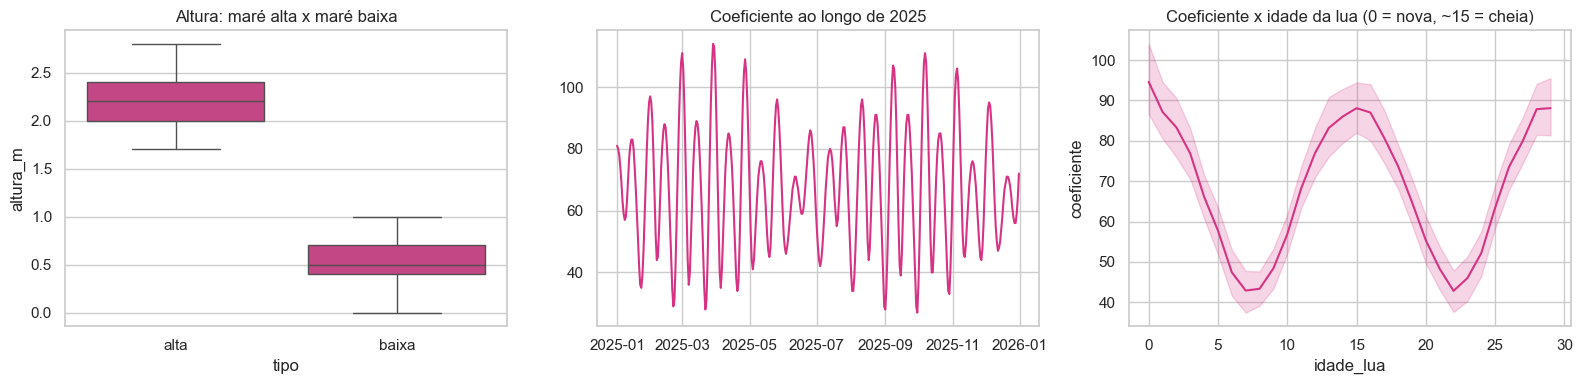

In [7]:
dias = mares.drop_duplicates("data")
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=mares, x="tipo", y="altura_m", ax=ax[0])
ax[0].set_title("Altura: maré alta x maré baixa")

ax[1].plot(dias["data"], dias["coeficiente"])
ax[1].set_title("Coeficiente ao longo de 2025")

sns.lineplot(data=dias, x="idade_lua", y="coeficiente", ax=ax[2])
ax[2].set_title("Coeficiente x idade da lua (0 = nova, ~15 = cheia)")
plt.tight_layout()

**Leitura — marés:**

- **Alta × baixa:** as duas distribuições não se sobrepõem. Maré alta fica
  entre 1,7 e 2,8 m (mediana 2,2 m); maré baixa entre 0,0 e 1,0 m (mediana
  0,5 m). A amplitude típica é de ~1,7 m.
- **Coeficiente no ano:** oscila o ano todo num ciclo de ~15 dias (entre ~40 e
  ~100), mas a média mensal quase não muda (66 a 72). Não existe "mês de maré
  forte" — o que manda é a semana.
- **Coeficiente × lua:** relação clara. O coeficiente é máximo perto da lua
  nova (idade 0) e da lua cheia (~15) — as marés de sizígia — e mínimo nos
  quartos crescente e minguante (~7 e ~22), as marés de quadratura.

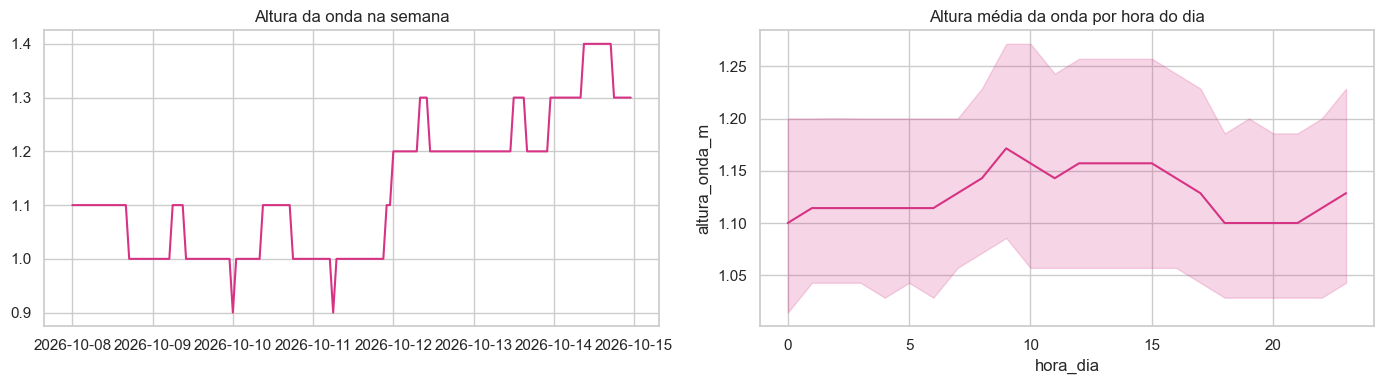

In [8]:
ondas["hora_dia"] = ondas["datahora"].dt.hour

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(ondas["datahora"], ondas["altura_onda_m"])
ax[0].set_title("Altura da onda na semana")

sns.lineplot(data=ondas, x="hora_dia", y="altura_onda_m", ax=ax[1])
ax[1].set_title("Altura média da onda por hora do dia")
plt.tight_layout()

**Leitura — ondas:**

- **Faixa:** entre 0,9 e 1,4 m na janela, média de 1,1 m. Mar pequeno a médio.
- **Padrão:** a variação é de **um dia para o outro**, não ao longo do dia. De
  8 a 11/out a onda fica em ~1,0 m; a partir de 12/out ela cresce até 1,4 m em
  14/out.
- **Por hora:** a curva média por hora é praticamente plana (diferença de
  ~0,05 m entre a hora mais alta e a mais baixa). A hora do dia quase não muda
  a altura da onda.

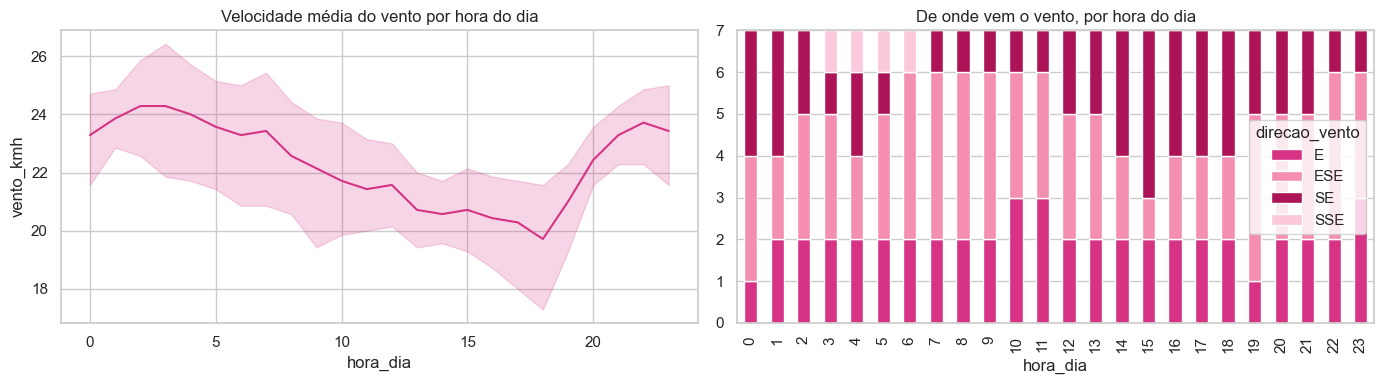

In [9]:
vento["hora_dia"] = vento["datahora"].dt.hour

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=vento, x="hora_dia", y="vento_kmh", ax=ax[0])
ax[0].set_title("Velocidade média do vento por hora do dia")

pd.crosstab(vento["hora_dia"], vento["direcao_vento"]).plot(kind="bar", stacked=True, ax=ax[1])
ax[1].set_title("De onde vem o vento, por hora do dia")
plt.tight_layout()

**Leitura — vento:**

- **Horas mais calmas:** fim da tarde, ~16h–18h (~20 km/h em média). O mais
  forte é de madrugada, ~1h–4h (~24 km/h). A diferença é pequena: venta o dia
  todo.
- **Direção:** sempre do quadrante **leste-sudeste** (E, ESE, SE, SSE), sem
  mudança clara ao longo do dia. Em João Pessoa o mar fica a leste, então esse
  é vento **do mar para a terra** (maral/onshore) — o tipo que bagunça a onda.
  Não aparece em nenhuma hora o vento de oeste (terral/offshore), o ideal para
  surf. Na prática, o que dá para escolher na janela é **a hora de vento mais
  fraco**, não a de vento bom.

## 4. Juntar as tabelas

Esta é a parte difícil, e ela tem mais de uma resposta certa.

As granularidades não batem: onda e vento são leituras horárias; maré são ~4
eventos por dia (os instantes de máxima e mínima). Para ter uma linha por hora
com as três informações você precisa decidir:

- Como levar a maré para a grade horária? Interpolar entre eventos? Repetir o
  último valor? Guardar apenas se a maré está subindo ou descendo? O que cada
  escolha assume sobre a curva real da maré — e onde essa suposição erra?
- Qual o tipo de junção? A previsão de onda e a de vento cobrem exatamente as
  mesmas horas? Se não, você mantém as horas incompletas ou corta?
- Que variáveis derivadas de tempo ajudam a responder a pergunta do projeto
  (dia da semana, período do dia, ...)?

Justifique as escolhas em markdown. Elas são a base das duas próximas etapas.

In [10]:
import numpy as np

# 1) onda + vento: mesma grade horária (conferido na seção 2), junção interna por datahora
df = ondas[["datahora", "data", "altura_onda_m", "direcao_onda"]].merge(
    vento[["datahora", "vento_kmh", "direcao_vento"]], on="datahora", how="inner"
)

# 2) maré na grade horária: interpolação por cosseno entre o evento anterior e o próximo
eventos = mares_prev.sort_values("datahora")
t_ev = eventos["datahora"].to_numpy()
h_ev = eventos["altura_m"].to_numpy()
alta_ev = (eventos["tipo"] == "alta").to_numpy()

t = df["datahora"].to_numpy()
prox = np.searchsorted(t_ev, t, side="right")  # índice do próximo evento de maré
assert (prox > 0).all() and (prox < len(t_ev)).all(), "a tábua não cobre a janela inteira"

t0, t1 = t_ev[prox - 1], t_ev[prox]
h0, h1 = h_ev[prox - 1], h_ev[prox]
frac = (t - t0) / (t1 - t0)  # 0 no evento anterior, 1 no próximo
df["altura_mare_m"] = (h0 + (h1 - h0) * (1 - np.cos(np.pi * frac)) / 2).round(2)
df["mare_subindo"] = alta_ev[prox]  # se o próximo evento é maré alta, a maré está subindo

# quanto a interpolação linear erraria em relação à de cosseno
linear = h0 + (h1 - h0) * frac
print(f"diferença máxima cosseno x linear: {np.abs(df['altura_mare_m'] - linear).max():.2f} m")
df.head()

diferença máxima cosseno x linear: 0.26 m


,datahora,data,altura_onda_m,direcao_onda,vento_kmh,direcao_vento,altura_mare_m,mare_subindo
0,2026-10-08 00:00:00,2026-10-08,1.1,E,21.0,SE,1.85,True
1,2026-10-08 01:00:00,2026-10-08,1.1,E,22.0,SE,2.23,True
2,2026-10-08 02:00:00,2026-10-08,1.1,E,20.0,SE,2.40,True
3,2026-10-08 03:00:00,2026-10-08,1.1,E,18.0,SSE,2.31,False
4,2026-10-08 04:00:00,2026-10-08,1.1,E,18.0,SSE,1.99,False


In [11]:
# 3) informação diária da tábua (coeficiente, lua, sol): repetida nas 24 horas do dia
diario = mares_prev.drop_duplicates("data")[["data", "coeficiente", "idade_lua", "nascer_sol", "por_sol"]]
df = df.merge(diario, on="data", how="left")

# 4) variáveis de tempo
df["hora_dia"] = df["datahora"].dt.hour
df["dia_semana"] = df["datahora"].dt.dayofweek.map(dict(enumerate(["seg", "ter", "qua", "qui", "sex", "sáb", "dom"])))
df["periodo"] = pd.cut(df["hora_dia"], bins=[0, 6, 12, 18, 24], right=False,
                       labels=["madrugada", "manhã", "tarde", "noite"])
hhmm = df["datahora"].dt.strftime("%H:%M")
df["luz_do_dia"] = (hhmm >= df["nascer_sol"]) & (hhmm <= df["por_sol"])

df = df.drop(columns=["nascer_sol", "por_sol"])
df.head()

,datahora,data,altura_onda_m,direcao_onda,vento_kmh,direcao_vento,altura_mare_m,mare_subindo,coeficiente,idade_lua,hora_dia,dia_semana,periodo,luz_do_dia
0,2026-10-08 00:00:00,2026-10-08,1.1,E,21.0,SE,1.85,True,91,27,0,qui,madrugada,False
1,2026-10-08 01:00:00,2026-10-08,1.1,E,22.0,SE,2.23,True,91,27,1,qui,madrugada,False
2,2026-10-08 02:00:00,2026-10-08,1.1,E,20.0,SE,2.40,True,91,27,2,qui,madrugada,False
3,2026-10-08 03:00:00,2026-10-08,1.1,E,18.0,SSE,2.31,False,91,27,3,qui,madrugada,False
4,2026-10-08 04:00:00,2026-10-08,1.1,E,18.0,SSE,1.99,False,91,27,4,qui,madrugada,False


(168, 14)
nulos: 0 | horários repetidos: 0
horas com luz do dia: 91 de 168


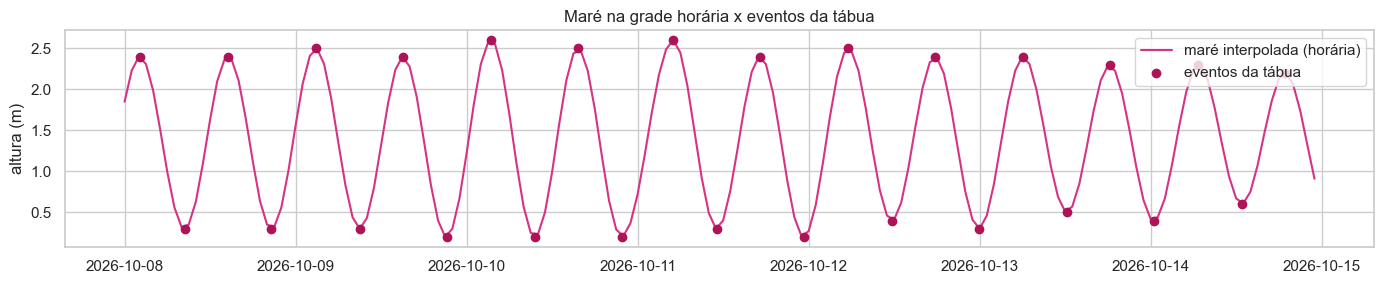

In [12]:
print(df.shape)
print("nulos:", df.isna().sum().sum(), "| horários repetidos:", df["datahora"].duplicated().sum())
print("horas com luz do dia:", df["luz_do_dia"].sum(), "de", len(df))

# conferência visual: a curva interpolada passa pelos eventos da tábua?
janela = eventos[eventos["datahora"].between(df["datahora"].min(), df["datahora"].max())]
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df["datahora"], df["altura_mare_m"], label="maré interpolada (horária)")
ax.scatter(janela["datahora"], janela["altura_m"], color=ROSAS[2], zorder=3, label="eventos da tábua")
ax.set_title("Maré na grade horária x eventos da tábua")
ax.set_ylabel("altura (m)")
ax.legend(loc="upper right")
plt.tight_layout()

**Decisões da junção:**

- **Onda + vento:** junção interna (`inner`) por `datahora`. As duas previsões
  cobrem exatamente as mesmas 168 horas (conferido na seção 2), então nenhuma
  hora se perde. Se um dia não batessem, o `inner` cortaria as horas
  incompletas — preferível a inventar onda ou vento.
- **Maré → grade horária:** interpolei a altura entre cada par de eventos
  consecutivos (alta → baixa ou baixa → alta) com um **cosseno**, e guardei
  também `mare_subindo`. O cosseno assume que, entre uma alta e uma baixa, a
  maré desce devagar perto dos extremos e rápido no meio — que é como uma maré
  semidiurna se comporta (a "regra dos doze avos"). A interpolação linear faria
  um zigue-zague e erraria até **0,26 m** nesta janela, justamente perto das
  marés altas e baixas. Repetir o último valor seria pior: a maré ficaria
  "parada" por 6 horas.
- **Onde a suposição erra:** a maré real não é um cosseno perfeito — em águas
  rasas a subida e a descida têm durações diferentes, e vento forte e pressão
  atmosférica empurram o nível do mar para cima ou para baixo (a tábua é
  astronômica e não sabe disso). As alturas da tábua também vêm arredondadas a
  0,1 m. O erro deve ser de poucos centímetros a ~0,1–0,2 m.
- **Cobertura:** a tábua usada é a de outubro/2026 (`mares_previsao.csv`). Ela
  cobre a janela inteira, inclusive o evento da noite de 7/out, necessário para
  interpolar a 0h de 8/out. Se a previsão cruzasse para novembro, faltaria
  maré — o `assert` acusa isso.
- **Variáveis derivadas:** `hora_dia`, `dia_semana` e `periodo` (madrugada,
  manhã, tarde, noite) para responder "que dia e que horário"; `luz_do_dia`
  (entre o nascer e o pôr do sol), porque ninguém surfa às 2h da manhã;
  `coeficiente` e `idade_lua` são diários e foram repetidos nas 24 horas.

## 5. Visualizações voltadas à pergunta

Agora com a tabela junta: quando as condições coincidem?

- As horas de onda maior são as mesmas de vento mais fraco, ou elas se
  desencontram?
- Existe relação visível entre altura da maré e altura da onda?
- Quais dias e horas da janela se destacam?

Prefira poucos gráficos legíveis a muitos gráficos.

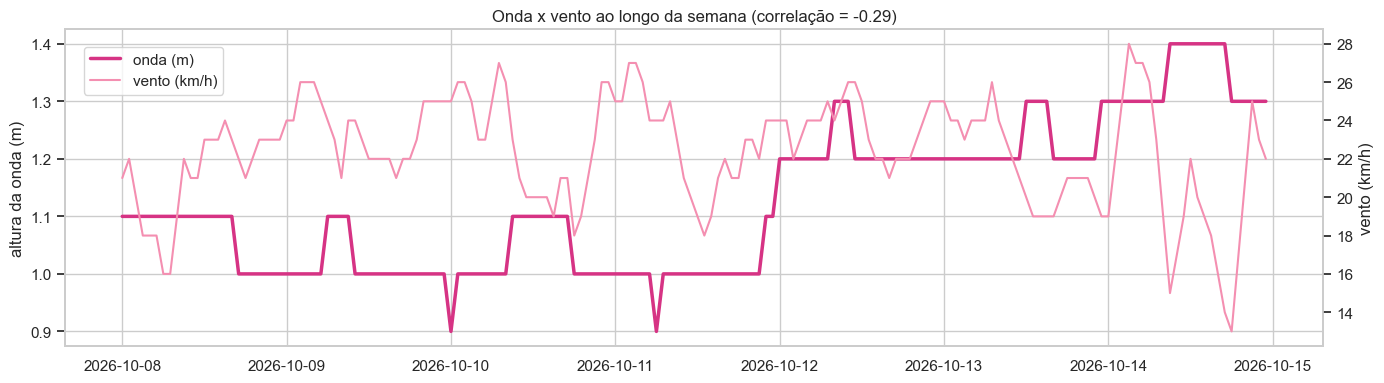

In [13]:
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(df["datahora"], df["altura_onda_m"], color=ROSAS[0], linewidth=2.5, label="onda (m)")
ax1.set_ylabel("altura da onda (m)")

ax2 = ax1.twinx()
ax2.plot(df["datahora"], df["vento_kmh"], color=ROSAS[1], label="vento (km/h)")
ax2.set_ylabel("vento (km/h)")
ax2.grid(False)

corr = df["altura_onda_m"].corr(df["vento_kmh"])
ax1.set_title(f"Onda x vento ao longo da semana (correlação = {corr:.2f})")
fig.legend(loc="upper left", bbox_to_anchor=(0.06, 0.88))
plt.tight_layout()

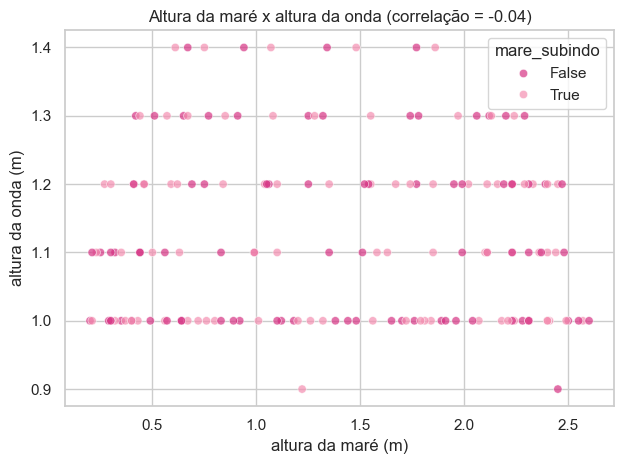

In [14]:
corr = df["altura_mare_m"].corr(df["altura_onda_m"])
ax = sns.scatterplot(data=df, x="altura_mare_m", y="altura_onda_m", hue="mare_subindo", alpha=0.7)
ax.set_title(f"Altura da maré x altura da onda (correlação = {corr:.2f})")
ax.set_xlabel("altura da maré (m)")
ax.set_ylabel("altura da onda (m)")
plt.tight_layout()

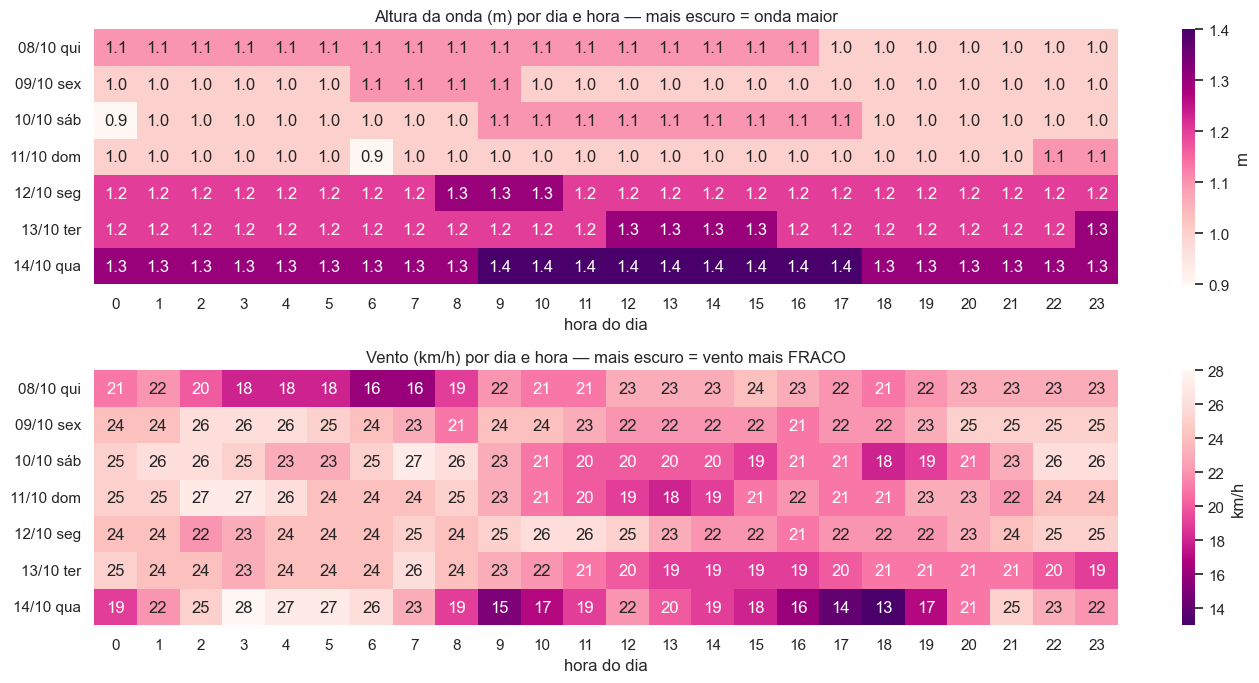

In [15]:
dia = df["datahora"].dt.strftime("%d/%m ") + df["dia_semana"].astype(str)
onda_grade = df.pivot_table(index=dia, columns="hora_dia", values="altura_onda_m")
vento_grade = df.pivot_table(index=dia, columns="hora_dia", values="vento_kmh")

fig, ax = plt.subplots(2, 1, figsize=(14, 7))
sns.heatmap(onda_grade, cmap="RdPu", annot=True, fmt=".1f", cbar_kws={"label": "m"}, ax=ax[0])
ax[0].set_title("Altura da onda (m) por dia e hora — mais escuro = onda maior")
sns.heatmap(vento_grade, cmap="RdPu_r", annot=True, fmt=".0f", cbar_kws={"label": "km/h"}, ax=ax[1])
ax[1].set_title("Vento (km/h) por dia e hora — mais escuro = vento mais FRACO")
for a in ax:
    a.set_xlabel("hora do dia")
    a.set_ylabel("")
plt.tight_layout()

**Leitura:**

- **Onda × vento:** não andam juntos — a correlação é fraca e negativa
  (−0,29). A onda cresce de 12 a 14/out sem o vento aumentar; o vento oscila
  dentro de cada dia (mais fraco à tarde), enquanto a onda muda de um dia para o
  outro. Ou seja, onda maior **não** vem acompanhada de vento mais forte nesta
  janela, e isso é bom: dá para ter as duas coisas ao mesmo tempo.
- **Maré × onda:** nenhuma relação (correlação ≈ 0). Faz sentido: a previsão
  de onda vem do swell que chega do oceano, que não depende da maré. A maré
  importa para **como** a onda quebra na praia, não para o tamanho dela — por
  isso ela precisa entrar na regra da Etapa 3 como uma variável separada.
- **Dias e horas que se destacam:** **14/out (quarta)** é o melhor dia da
  janela — a maior onda (1,3–1,4 m, com 1,4 m das 9h às 17h) e os ventos mais
  fracos da semana (15 km/h às 9h, 13–14 km/h às 17h–18h). 12 e 13/out vêm em seguida, com
  onda de 1,2–1,3 m; em 13/out o vento cai para ~19 km/h no começo da tarde. De
  8 a 11/out a onda fica em ~1,0 m — os piores dias.

## 6. Salvar o dataset processado

Grave o resultado em `../data/processed/dataset.csv`. A Etapa 3 lê esse
arquivo — se as colunas mudarem depois, o notebook de ML muda também.

In [16]:
df.to_csv(DIR_PROC / "dataset.csv", index=False)

conferencia = pd.read_csv(DIR_PROC / "dataset.csv")
print(conferencia.shape)
conferencia.dtypes

(168, 14)


datahora             str
data                 str
altura_onda_m    float64
direcao_onda         str
vento_kmh        float64
direcao_vento        str
altura_mare_m    float64
mare_subindo        bool
coeficiente        int64
idade_lua          int64
hora_dia           int64
dia_semana           str
periodo              str
luz_do_dia          bool
dtype: object

Colunas do `dataset.csv` (uma linha por hora, 8 a 14/out/2026):

| coluna | o que é |
|---|---|
| `datahora`, `data` | instante da leitura e o dia |
| `altura_onda_m`, `direcao_onda` | previsão de onda |
| `vento_kmh`, `direcao_vento` | previsão de vento (direção ainda como texto: a Etapa 3 decide como codificar) |
| `altura_mare_m`, `mare_subindo` | maré interpolada por cosseno e se está enchendo |
| `coeficiente`, `idade_lua` | diários, da tábua (0 = lua nova, ~15 = cheia) |
| `hora_dia`, `dia_semana`, `periodo`, `luz_do_dia` | variáveis de tempo |

## 7. Conclusões

Em texto, sem código:

1. O que os dados mostram sobre as condições da janela coletada?
2. Que decisão de limpeza ou de junção você tomou que mais influencia o
   resultado, e por quê?
3. O que esses dados **não** permitem afirmar?

**1. O que os dados mostram sobre a janela (8 a 14/out/2026)?**

O mar está pequeno/médio (0,9–1,4 m) e venta o tempo todo do mar para a
terra. A onda melhora a partir de 12/out e o melhor dia é 14/out: 1,4 m das 9h às 17h e
os ventos mais fracos da semana (15 km/h às 9h, 13–14 km/h às 17h–18h).
Dentro de um dia, a onda quase não muda; o que muda é o vento, que costuma
ser mais fraco à tarde. A maré não tem relação com o tamanho da onda.

**2. Que decisão mais influencia o resultado, e por quê?**
A decisão que mais pesa é como calcular a maré de hora em hora, já que o site só dá cerca de 4 horários de maré por dia, entao usei uma curva com o cosseno, porque a maré real muda devagar perto da maré alta e da baixa e mais rápido no meio. Se eu ligasse os pontos com retas, a altura poderia errar até 0,26 m. Se eu repetisse o último valor, a maré ficaria parada por 6 horas. Isso importa porque a maré vai entrar na regra de “bom para surfar” da Etapa 3.
**3. O que esses dados não permitem afirmar?**

- **Qual a melhor época do ano.** Onda e vento só existem em  7 dias de
  outubro de 2026. A tábua de marés de 2025 cobre o ano inteiro, mas maré
  sozinha não diz se tem onda e a seção 5 mostrou que a altura da maré não
  tem relação com a altura da onda (deu uma correlacao de 0.04).
- **Que um padrão se repete.** Com 7 dias, "a onda cresce no fim da semana" ou
  "o vento é mais fraco à tarde" podem ser só desta semana. Não dá para separar
  padrão de coincidência.
- **Se a onda é boa, e não só grande.** Falta o período do swell, que pesa tanto quanto a altura, e a direção do
  swell em graus — o site só dá a direção em pontos cardeais (E, ESE, ...).
- **Qual praia escolher.**
A mesma onda e o mesmo vento chegam diferentes em cada praia. Isso depende do fundo do mar (os recifes, como o Picãozinho, seguram a onda na maré baixa) e de para onde cada trecho da orla está. Para decidir a melhor praia, seriam necessários dados de cada pico, e não um único pra a cidade inteira.